In [149]:
import pandas as pd

In [150]:
Kdata = pd.read_csv("C:/Users/JANANI V/Desktop/MDP_GUVI/Datas/kidney_disease.csv")

In [151]:
Kdata.isnull().sum()

id                  0
age                 9
bp                 12
sg                 47
al                 46
su                 49
rbc               152
pc                 65
pcc                 4
ba                  4
bgr                44
bu                 19
sc                 17
sod                87
pot                88
hemo               52
pcv                70
wc                105
rc                130
htn                 2
dm                  2
cad                 2
appet               1
pe                  1
ane                 1
classification      0
dtype: int64

In [152]:
print(Kdata.isna().sum())  # Count missing values per column


id                  0
age                 9
bp                 12
sg                 47
al                 46
su                 49
rbc               152
pc                 65
pcc                 4
ba                  4
bgr                44
bu                 19
sc                 17
sod                87
pot                88
hemo               52
pcv                70
wc                105
rc                130
htn                 2
dm                  2
cad                 2
appet               1
pe                  1
ane                 1
classification      0
dtype: int64


In [153]:
zero_counts = (Kdata == 0).sum()
print(zero_counts)


id                  1
age                 0
bp                  0
sg                  0
al                199
su                290
rbc                 0
pc                  0
pcc                 0
ba                  0
bgr                 0
bu                  0
sc                  0
sod                 0
pot                 0
hemo                0
pcv                 0
wc                  0
rc                  0
htn                 0
dm                  0
cad                 0
appet               0
pe                  0
ane                 0
classification      0
dtype: int64


In [154]:
Kdata.drop(columns=["su"], inplace=True)


In [155]:
zero_counts = (Kdata == 0).sum()
print(zero_counts)


id                  1
age                 0
bp                  0
sg                  0
al                199
rbc                 0
pc                  0
pcc                 0
ba                  0
bgr                 0
bu                  0
sc                  0
sod                 0
pot                 0
hemo                0
pcv                 0
wc                  0
rc                  0
htn                 0
dm                  0
cad                 0
appet               0
pe                  0
ane                 0
classification      0
dtype: int64


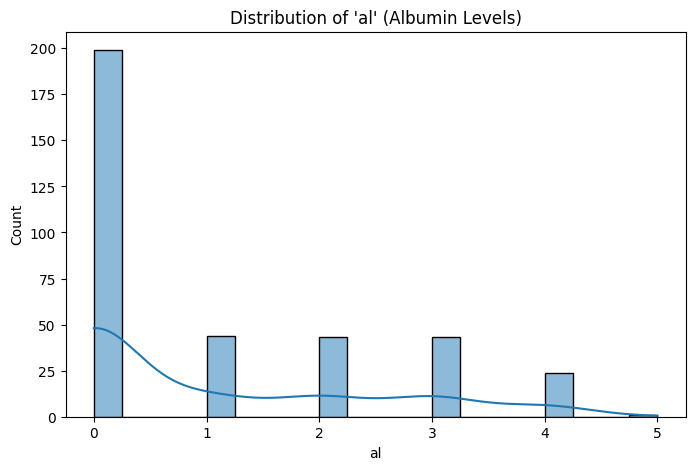

In [156]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
sns.histplot(Kdata["al"], bins=20, kde=True)
plt.title("Distribution of 'al' (Albumin Levels)")
plt.show()


In [157]:
Kdata["al"] = Kdata["al"].replace(0, 0.1)


In [158]:
Kdata["al"].fillna(Kdata["al"].mean())


0      1.0
1      4.0
2      2.0
3      4.0
4      2.0
      ... 
395    0.1
396    0.1
397    0.1
398    0.1
399    0.1
Name: al, Length: 400, dtype: float64

In [159]:
Kdata.drop(columns=["id"], inplace=True)


In [160]:
print(Kdata.isna().sum())  # Count missing values per column


age                 9
bp                 12
sg                 47
al                 46
rbc               152
pc                 65
pcc                 4
ba                  4
bgr                44
bu                 19
sc                 17
sod                87
pot                88
hemo               52
pcv                70
wc                105
rc                130
htn                 2
dm                  2
cad                 2
appet               1
pe                  1
ane                 1
classification      0
dtype: int64


In [161]:
print((Kdata == "").sum())  # Counts empty strings across all columns


age               0
bp                0
sg                0
al                0
rbc               0
pc                0
pcc               0
ba                0
bgr               0
bu                0
sc                0
sod               0
pot               0
hemo              0
pcv               0
wc                0
rc                0
htn               0
dm                0
cad               0
appet             0
pe                0
ane               0
classification    0
dtype: int64


In [162]:
import numpy as np

# Replace '?' with NaN in the entire dataset
Kdata.replace("?",  np.nan, inplace=True)
Kdata.replace("  ",  np.nan, inplace=True)


In [163]:
from sklearn.impute import SimpleImputer

num_features = ["age", "bp", "bgr", "bu", "sc", "sod", "pot", "hemo", "pcv", "wc", "rc"]
num_imputer = SimpleImputer(strategy="median")  # Fill missing values with median
Kdata[num_features] = num_imputer.fit_transform(Kdata[num_features])


In [164]:
cat_features = ["rbc", "pc", "pcc", "ba", "htn", "dm", "cad", "appet", "pe", "ane"]
cat_imputer = SimpleImputer(strategy="most_frequent")  # Fill missing values with mode
Kdata[cat_features] = cat_imputer.fit_transform(Kdata[cat_features])


In [165]:
print(Kdata['al'].mean())
  # Show the actual median value


1.0731638418079095


In [166]:
# Fill missing values
Kdata["sg"] = Kdata["sg"].fillna(Kdata["sg"].median())  # Median for continuous feature
Kdata["al"]=Kdata["al"].replace(0.1,1.0169491525423728) 


In [167]:
Kdata['al'].value_counts()

al
1.016949    199
1.000000     44
3.000000     43
2.000000     43
4.000000     24
5.000000      1
Name: count, dtype: int64

In [168]:
Kdata["al"] = Kdata["al"].fillna(Kdata["al"].mean())  # Fill NaN with mean of 'al'


In [169]:
Kdata['al'].value_counts()

al
1.016949    199
1.588624     46
1.000000     44
3.000000     43
2.000000     43
4.000000     24
5.000000      1
Name: count, dtype: int64

In [170]:
Kdata.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 24 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             400 non-null    float64
 1   bp              400 non-null    float64
 2   sg              400 non-null    float64
 3   al              400 non-null    float64
 4   rbc             400 non-null    object 
 5   pc              400 non-null    object 
 6   pcc             400 non-null    object 
 7   ba              400 non-null    object 
 8   bgr             400 non-null    float64
 9   bu              400 non-null    float64
 10  sc              400 non-null    float64
 11  sod             400 non-null    float64
 12  pot             400 non-null    float64
 13  hemo            400 non-null    float64
 14  pcv             400 non-null    float64
 15  wc              400 non-null    float64
 16  rc              400 non-null    float64
 17  htn             400 non-null    obj

In [171]:
Kdata.describe(include="all")


,age,bp,sg,al,rbc,pc,pcc,ba,bgr,bu,...,pcv,wc,rc,htn,dm,cad,appet,pe,ane,classification
count,400.000000,400.000000,400.000000,400.000000,400,400,400,400,400.000000,400.000000,...,400.000000,400.000000,400.000000,400,400,400,400,400,400,400
unique,NaN,NaN,NaN,NaN,2,2,2,2,NaN,NaN,...,NaN,NaN,NaN,2,2,2,2,2,2,2
top,NaN,NaN,NaN,NaN,normal,normal,notpresent,notpresent,NaN,NaN,...,NaN,NaN,NaN,no,no,no,good,no,no,ckd
freq,NaN,NaN,NaN,NaN,353,324,358,378,NaN,NaN,...,NaN,NaN,NaN,253,263,366,318,324,340,250
mean,51.562500,76.575000,1.017712,1.588624,NaN,NaN,NaN,NaN,145.062500,56.693000,...,39.082500,8298.500000,4.737750,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,16.982996,13.489785,0.005434,0.901689,NaN,NaN,NaN,NaN,75.260774,49.395258,...,8.162245,2529.593814,0.841439,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,2.000000,50.000000,1.005000,1.000000,NaN,NaN,NaN,NaN,22.000000,1.500000,...,9.000000,2200.000000,2.100000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,42.000000,70.000000,1.015000,1.016949,NaN,NaN,NaN,NaN,101.000000,27.000000,...,34.000000,6975.000000,4.500000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,55.000000,80.000000,1.020000,1.016949,NaN,NaN,NaN,NaN,121.000000,42.000000,...,40.000000,8000.000000,4.800000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,64.000000,80.000000,1.020000,2.000000,NaN,NaN,NaN,NaN,150.000000,61.750000,...,44.000000,9400.000000,5.100000,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [172]:
Kdata[["htn", "dm", "cad", "appet", "pe", "ane"]].value_counts()


htn  dm   cad  appet  pe   ane
no   no   no   good   no   no     191
yes  yes  no   good   no   no      27
no   yes  no   good   no   no      18
yes  yes  no   poor   yes  no      15
     no   no   good   no   no      12
     yes  no   good   no   yes     12
no   no   no   good   yes  no       9
               poor   no   no       8
yes  yes  no   good   yes  no       8
               poor   no   no       7
          yes  good   no   no       7
               poor   yes  no       6
          no   poor   yes  yes      6
                      no   yes      5
     no   no   good   no   yes      5
                      yes  yes      4
no   no   no   poor   yes  yes      4
               good   no   yes      4
yes  no   no   poor   no   no       4
no   yes  no   poor   no   no       3
yes  yes  yes  good   yes  no       3
               poor   no   no       3
     no   yes  good   no   no       3
no   yes  no   good   yes  no       3
yes  no   no   poor   yes  yes      3
                   

In [173]:
from sklearn.preprocessing import LabelEncoder

binary_features = ["htn", "dm", "cad", "appet", "pe", "ane"]
label_encoder = LabelEncoder()

for col in binary_features:
    Kdata[col] = label_encoder.fit_transform(Kdata[col])  # Convert categorical to numerical


In [174]:
for col in binary_features:
    print(Kdata[col].value_counts())


htn
0    253
1    147
Name: count, dtype: int64
dm
0    263
1    137
Name: count, dtype: int64
cad
0    366
1     34
Name: count, dtype: int64
appet
0    318
1     82
Name: count, dtype: int64
pe
0    324
1     76
Name: count, dtype: int64
ane
0    340
1     60
Name: count, dtype: int64


In [175]:
from sklearn.preprocessing import OrdinalEncoder

ordinal_features = [ "rbc", "pc", "pcc", "ba"]
ordinal_encoder = OrdinalEncoder()

Kdata[ordinal_features] = ordinal_encoder.fit_transform(Kdata[ordinal_features])
print(Kdata[ordinal_features].value_counts())

rbc  pc   pcc  ba 
1.0  1.0  0.0  0.0    295
     0.0  0.0  0.0     20
          1.0  0.0     18
0.0  1.0  0.0  0.0     16
     0.0  0.0  0.0     15
1.0  0.0  1.0  1.0      8
0.0  0.0  1.0  0.0      7
1.0  1.0  1.0  0.0      6
0.0  0.0  0.0  1.0      6
1.0  1.0  0.0  1.0      3
     0.0  0.0  1.0      2
0.0  1.0  1.0  1.0      1
               0.0      1
          0.0  1.0      1
1.0  1.0  1.0  1.0      1
Name: count, dtype: int64


In [176]:
# Convert classification labels
Kdata["classification"] = Kdata["classification"].replace({"notckd": 0, "ckd": 1}).astype("int64")


C:\Users\JANANI V\AppData\Local\Temp\ipykernel_5348\590569894.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  Kdata["classification"] = Kdata["classification"].replace({"notckd": 0, "ckd": 1}).astype("int64")


In [177]:
Kdata.describe(include="all")


,age,bp,sg,al,rbc,pc,pcc,ba,bgr,bu,...,pcv,wc,rc,htn,dm,cad,appet,pe,ane,classification
count,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000,...,400.000000,400.000000,400.000000,400.000000,400.00000,400.000000,400.000000,400.000000,400.000000,400.000000
mean,51.562500,76.575000,1.017712,1.588624,0.882500,0.810000,0.105000,0.055000,145.062500,56.693000,...,39.082500,8298.500000,4.737750,0.367500,0.34250,0.085000,0.205000,0.190000,0.150000,0.625000
std,16.982996,13.489785,0.005434,0.901689,0.322418,0.392792,0.306937,0.228266,75.260774,49.395258,...,8.162245,2529.593814,0.841439,0.482728,0.47514,0.279231,0.404207,0.392792,0.357519,0.484729
min,2.000000,50.000000,1.005000,1.000000,0.000000,0.000000,0.000000,0.000000,22.000000,1.500000,...,9.000000,2200.000000,2.100000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,42.000000,70.000000,1.015000,1.016949,1.000000,1.000000,0.000000,0.000000,101.000000,27.000000,...,34.000000,6975.000000,4.500000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,55.000000,80.000000,1.020000,1.016949,1.000000,1.000000,0.000000,0.000000,121.000000,42.000000,...,40.000000,8000.000000,4.800000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,1.000000
75%,64.000000,80.000000,1.020000,2.000000,1.000000,1.000000,0.000000,0.000000,150.000000,61.750000,...,44.000000,9400.000000,5.100000,1.000000,1.00000,0.000000,0.000000,0.000000,0.000000,1.000000
max,90.000000,180.000000,1.025000,5.000000,1.000000,1.000000,1.000000,1.000000,490.000000,391.000000,...,54.000000,26400.000000,8.000000,1.000000,1.00000,1.000000,1.000000,1.000000,1.000000,1.000000


In [178]:
Kdata["classification"] = Kdata["classification"].replace({"ckd": 1, "notckd": 0})
Kdata["classification"].value_counts()

classification
1    250
0    150
Name: count, dtype: int64

In [179]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(sampling_strategy="auto", random_state=42)
X, y = smote.fit_resample(Kdata.drop(columns=["classification"]), Kdata["classification"])


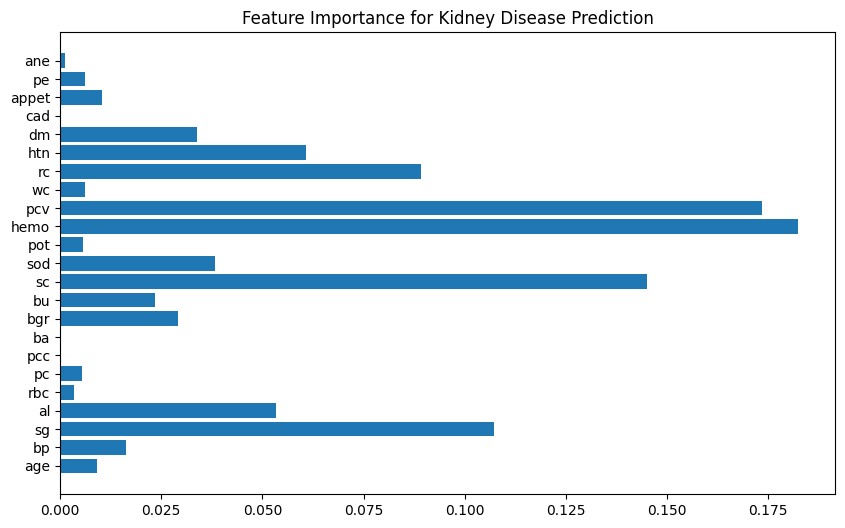

In [180]:
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt

# Train model
rf_model = RandomForestClassifier()
rf_model.fit(X, y)

# Plot feature importance
plt.figure(figsize=(10, 6))
plt.barh(X.columns, rf_model.feature_importances_)
plt.title("Feature Importance for Kidney Disease Prediction")
plt.show()


In [181]:
#selecting important features based on feature importance
important_features = ["hemo", "pcv", "sg", "sc", "bgr", "bu"]
X = Kdata[important_features]
y= Kdata["classification"]

In [182]:
from imblearn.over_sampling import SMOTE
from sklearn.utils import resample

# Apply SMOTE first (oversampling minority class)
smote = SMOTE(random_state=42)
X_smote, y_smote = smote.fit_resample(X, y)

# Downsample majority class after SMOTE
X_majority = X_smote[y_smote == 1]
X_minority = X_smote[y_smote == 0]

X_majority_downsampled = resample(X_majority, replace=False, n_samples=len(X_minority), random_state=42)

# Combine balanced datasets
X_balanced = np.vstack((X_minority, X_majority_downsampled))
y_balanced = np.concatenate((y_smote[y_smote == 0], y_smote[y_smote == 1][:len(X_minority)]))

print("Balanced dataset:", dict(zip(*np.unique(y_balanced, return_counts=True))))


Balanced dataset: {np.int64(0): np.int64(250), np.int64(1): np.int64(250)}


In [183]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# Apply scaling after balancing dataset
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_balanced)

# Now split data into training & test sets
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y_balanced, test_size=0.2, random_state=42)


In [184]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# ✅ Logistic Regression
log_model = LogisticRegression()
log_model.fit(X_train, y_train)  # Using correctly named balanced & scaled data

# Get probabilities instead of raw predictions
y_prob_log = log_model.predict_proba(X_test)[:, 1]  # Extract probability of class '1'
y_pred_log = (y_prob_log >= 0.55).astype(int)  # Adjust threshold

print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_log))
print("LR Classification Report:\n", classification_report(y_test, y_pred_log))

# ✅ Random Forest
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Adjust probability threshold for better balance
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]
y_pred_rf = (y_prob_rf >= 0.55).astype(int)

print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print("RF Classification Report:\n", classification_report(y_test, y_pred_rf))

# ✅ XGBoost
xgb_model = XGBClassifier()
xgb_model.fit(X_train, y_train)

# Adjust probability threshold for better decision boundary
y_prob_xgb = xgb_model.predict_proba(X_test)[:, 1]
y_pred_xgb = (y_prob_xgb >= 0.55).astype(int)

print("XGBoost Accuracy:", accuracy_score(y_test, y_pred_xgb))
print("XGB Classification Report:\n", classification_report(y_test, y_pred_xgb))

# ✅ Confusion Matrices
print("Confusion Matrix for LR:\n", confusion_matrix(y_test, y_pred_log))
print("Confusion Matrix for RF:\n", confusion_matrix(y_test, y_pred_rf))
print("Confusion Matrix for XGB:\n", confusion_matrix(y_test, y_pred_xgb))


Logistic Regression Accuracy: 0.96
LR Classification Report:
               precision    recall  f1-score   support

           0       0.94      0.98      0.96        46
           1       0.98      0.94      0.96        54

    accuracy                           0.96       100
   macro avg       0.96      0.96      0.96       100
weighted avg       0.96      0.96      0.96       100

Random Forest Accuracy: 0.97
RF Classification Report:
               precision    recall  f1-score   support

           0       0.96      0.98      0.97        46
           1       0.98      0.96      0.97        54

    accuracy                           0.97       100
   macro avg       0.97      0.97      0.97       100
weighted avg       0.97      0.97      0.97       100

XGBoost Accuracy: 0.97
XGB Classification Report:
               precision    recall  f1-score   support

           0       0.98      0.96      0.97        46
           1       0.96      0.98      0.97        54

    accuracy 

In [185]:
import pickle

# Save the trained model
with open("kidney_disease_model.pkl", "wb") as file:
    pickle.dump(rf_model, file)
